# <center> Customer segmentation for an online gift shop

## Problem Statement


<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Marketing is an essential part of any business.
To increase profits, it's crucial for companies to understand their customers — their needs, preferences, and behavior. With the rise of e-commerce, collecting customer data, analyzing it, identifying patterns, and launching targeted marketing campaigns has become significantly easier.

Most online stores rely on web analytics tools to track page views, user sessions, visitor behavior, and bounce rates. However, a report from Google Analytics or a similar tool may not provide the full picture of how customers interact with the website. It's important for businesses to react quickly and accurately to changes in customer behavior by building tools that can detect these changes in near real-time.

Machine learning plays a key role in enabling platforms to process large volumes of customer data, identify behavioral patterns among different user segments, and classify customers into categories (such as loyal, potential, new, inactive, or churned). This allows businesses to tailor their communication and engagement strategies accordingly.

It’s also worth noting that companies leveraging machine learning in e-commerce can continuously improve business performance. For example, they can personalize product recommendations for each customer and offer pricing that matches their budget — a task that falls under the domain of recommender systems, which we’ll explore in the next section of the course.

> As a rule, e-commerce datasets are privately owned and therefore difficult to find among publicly available data.  However,[The UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/index.php)  create a dataset containing actual transactions from 2010 and 2011 was created, and this is the one we’ll be working with in this case study. 

> We’ll be working with a dataset that contains all transactions from December 1, 2010, to December 9, 2011, for a UK-based online retail company. The company primarily sells unique gifts for various occasions, and many of its customers are wholesale buyers.


**Business Objective:** Segment the existing customer base, interpret the identified segments, and define a strategy for engaging with each of them.

**Technical Objective (as a Data Science specialist):** Build a customer clustering model based on purchasing behavior — including monetary value, purchase frequency, and recency — and define the profile of each resulting cluster.

**Main Project Objectives:**
1. Perform preprocessing of the initial transaction dataset.
2. Conduct exploratory data analysis (EDA) to identify key patterns and insights.
3. Generate a dataset containing features for each unique customer.
4. Build and compare multiple machine learning models for customer clustering, determine the optimal number of clusters, and interpret the characteristics of each group.
5. Design a process for predicting a customer's interest category and test the model on new customer data.




## Data and Description

The dataset is provided as a CSV file, where each row represents a unique transaction.

Features included:

* InvoiceNo — Invoice number (a unique six-digit identifier for each transaction; invoices starting with "C" indicate a cancellation).

* StockCode — Item code (a unique five-digit code assigned to each product).

* Description — Item name.

* Quantity — Number of items purchased in the transaction.

* InvoiceDate — Date and time of the invoice/transaction.

* UnitPrice — Price per unit (in GBP).

* CustomerID — Customer identifier (a unique five-digit number assigned to each customer).

* Country — Country where the customer resides.



Importing basic libraries:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

import warnings 

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

## 1. Exploring the structure of the dataset

The first step is to understand the structure and content of the dataset and perform basic preprocessing — including converting features into appropriate formats for further analysis.

Tasks at this stage include:

* Conduct a statistical overview of the raw data to examine the key ranges of numeric features.

* Identify how many unique customers made transactions during the given period.

* Determine the countries from which transactions were made.

* Check the dataset for missing values and duplicate records.

* Convert columns into proper formats (e.g., parsing date columns as datetime objects)

In [ ]:
# read the data
data = pd.read_csv(
    "data/data.csv", 
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str}
)
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [ ]:
# convert 'InvoceData' to  datetime objects
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
# Display the sales period
print('Date interval {} to {}'.format(data['InvoiceDate'].dt.date.min(), data['InvoiceDate'].dt.date.max()))

Date interval 2010-12-01 to 2011-12-09


In [5]:
# Display descriptive statistics for numerical features
data.describe()

,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


## 2. Data Transformation, Cleaning, and Analysis

### 2.1. Transaction Data Cleaning and Transformation

#### 2.1.1 Missing Values

Missing values in the CustomerID and Description columns indicate invalid or incomplete transactions and should be removed from the dataset.

**Note.** If you examine the distribution of missing values in the Description and CustomerID columns, you’ll notice that removing rows with missing CustomerID values also eliminates all missing values in Description. Therefore, it's sufficient to drop rows with null values in CustomerID


In [6]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df = data.copy()
df = df.dropna(subset='CustomerID')

In [9]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### 2.1.2.  Duplicates

Check the dataset for duplicate records and remove them if found.


In [10]:
df.duplicated().sum()

5225

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

0

#### 2.1.3. Transactions with Negative Item Quantities
From the data insights above, we’ve learned about how order cancellations are recorded. Later, when segmenting customers, we will assess their purchasing power — and to do so accurately, it’s essential to account for any product returns made by each customer.

To calculate the number of returns, we first need to determine how many unique items are listed in each transaction (basket) for every unique customer–order pair.


In [13]:
temp = df.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


**Note.** More than 16% of unique orders are returns. An interesting point: if we had calculated the number of return transactions using the original dataset — where each row represents a unique product within an order — we would have ended up with less than 1% returns. However, this figure would be misleading

You’ll now add a new feature to the transaction data called `QuantityCanceled`. ЭThis feature indicates the number of items that were later canceled for each transaction that has a corresponding return transaction. For transactions with no returns, this value will be 0. For transactions that show a negative quantity but have no matching counterpart in the data, the value will be left as  `NaN`.

To help with this, we’ve prepared a helper function called `get_quantity_canceled()`. his function takes the transaction table as input and returns a  `Series` indicating the number of canceled items for each transaction. If no corresponding transaction is found, the value is marked as `NaN`.

**Note**: The function does not handle edge cases where the return quantity exceeds the quantity in any single purchase transaction (e.g., if a customer made several purchases of the same item and then returned them all at once). You’re welcome to modify the function if you’d like to handle this scenario more accurately.

*Caution: Matching return transactions can be very time-consuming due to the large number of rows in the dataset.  Running the following code may take up to 20 minutes depending on your machine’s performance.*

In [14]:
def get_quantity_canceled(data):
    """Функция для создания признака количества отменённых заказов. 
    Функция принимает на вход таблицу и возвращает столбец, в котором указано количество отменённого впоследствии товара для кажой транзакции.
    Если транзакция с отрицательным количеством товара не имеет контрагента, данный признак помечается как NaN.

    Args:
        data (DataFrame): таблица с транзакциями

    Returns:
        Series: столбец с количеством отменённого товара
    """
    # Инициализируем нулями Series той же длины, что и столбцы таблицы.
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        # Создаём DataFrame из всех контрагентов
        df_test = data[(data['CustomerID'] == col['CustomerID']) &
                       (data['StockCode']  == col['StockCode']) & 
                       (data['InvoiceDate'] < col['InvoiceDate']) & 
                       (data['Quantity'] > 0)].copy()
        # Транзация-возврат не имеет контрагента — ничего не делаем
        if (df_test.shape[0] == 0): 
            # Помечаем столбец как пропуск
            quantity_canceled.loc[index] = np.nan
        # Транзакция-возврат имеет ровно одного контрагента
        # Добавляем количество отменённого товара в столбец QuantityCanceled 
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col['Quantity']       
        # Транзакция-возврат имеет несколько контрагентов
        # Задаём количество отменённого товара в столбец QuantityCanceled для той транзакции на покупку,
        # в которой количество товара больше количества товаров в транзакции-возврате.
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
            for ind, val in df_test.iterrows():
                if val['Quantity'] < -col['Quantity']: 
                    continue
                quantity_canceled.loc[ind] = -col['Quantity']
                break    
    return quantity_canceled

df['QuantityCanceled'] = get_quantity_canceled(data)

*Caution: Identifying matching return transactions can be time-consuming due to the large number of rows in the dataset. Running the code below may take up to 20 minutes, depending on your computer's performance.*

Check how many transactions in the dataset have no matching counterparts. If the number is small, remove them from the data.

Once you've processed the returns, delete the transactions with negative quantities — they are no longer needed



In [15]:
# Check transactions without counterparts
df['QuantityCanceled'].isnull().sum()

1303

In [ ]:
# remove transactions without counterparts
df = df.dropna(subset='QuantityCanceled')

In [ ]:
# remove returns
df = df[df['Quantity'] >= 0]

In [18]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,QuantityCanceled
count,392732.000000,392732,392732.000000,392732.000000
mean,13.153718,2011-07-10 19:15:24.576301568,3.125596,0.623672
min,1.000000,2010-12-01 08:26:00,0.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,0.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,0.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,0.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,80995.000000
std,181.588420,NaN,22.240725,175.554922


#### 2.1.4. Specialized Transactions

The next task is to handle special types of transactions, which are identified by Latin letters in the product codes.

There are six such types present in the data. Using regular expressions, find the StockCode values that start with letters (they may also include digits).

**Hint.** Use the pattern '^[a-zA-Z]+' to identify these entries.

To better understand what these codes represent, refer to the 'Description' column. For example, 'POST' stands for postal charges, 'C2' refers to carriage costs, and BANK CHARGES indicates banking fees.

Since these special operations do not reflect the customers’ purchasing behavior — as they are not related to actual products — we will remove them from the datase

In [19]:
# filtered specialized transactions
special_codes_df = df[df['StockCode'].str.match('^[a-zA-Z]+', na=False)]
# print specialized transactions
print(special_codes_df[['StockCode', 'Description']].drop_duplicates())

           StockCode                 Description
45              POST                     POSTAGE
1423              C2                    CARRIAGE
2239               M                      Manual
4406    BANK CHARGES                Bank Charges
157195          PADS  PADS TO MATCH ALL CUSHIONS
317507           DOT              DOTCOM POSTAGE


In [20]:
# clean data from specialized transactions
df_cleaned = df[~df['StockCode'].isin(special_codes_df['StockCode'].unique())]
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391183 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         391183 non-null  object        
 1   StockCode         391183 non-null  object        
 2   Description       391183 non-null  object        
 3   Quantity          391183 non-null  int64         
 4   InvoiceDate       391183 non-null  datetime64[ns]
 5   UnitPrice         391183 non-null  float64       
 6   CustomerID        391183 non-null  object        
 7   Country           391183 non-null  object        
 8   QuantityCanceled  391183 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 29.8+ MB


In [ ]:
# print numbers of rows with specialized transactions
print(df['StockCode'].isin(special_codes_df['StockCode'].unique()).sum())

1549


#### 2.1.5. Transactions with Items of Zero Cost

When reviewing the descriptive statistics, we can see that some items have a unit price of £0. These transactions make up less than 1% of the data and can be safely removed.

In [22]:
df_cleaned.describe()

,Quantity,InvoiceDate,UnitPrice,QuantityCanceled
count,391183.000000,391183,391183.000000,391183.000000
mean,13.179665,2011-07-10 19:37:28.017628416,2.874130,0.625725
min,1.000000,2010-12-01 08:26:00,0.000000,0.000000
25%,2.000000,2011-04-07 11:16:00,1.250000,0.000000
50%,6.000000,2011-07-31 12:05:00,1.950000,0.000000
75%,12.000000,2011-10-20 12:57:00,3.750000,0.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,80995.000000
std,181.907403,NaN,4.284639,175.902145


In [24]:
print((df_cleaned['UnitPrice'] == 0).sum())
percent_zero_price = (df_cleaned['UnitPrice'] == 0).mean() * 100
print(f"Transactions with price 0: {percent_zero_price:.2f}%")

33
Transactions with price 0: 0.01%


In [25]:
# remove transactions with 0 price
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]

In [26]:
df_cleaned.describe()

,Quantity,InvoiceDate,UnitPrice,QuantityCanceled
count,391150.000000,391150,391150.000000,391150.000000
mean,13.145300,2011-07-10 19:37:34.766713600,2.874372,0.625778
min,1.000000,2010-12-01 08:26:00,0.040000,0.000000
25%,2.000000,2011-04-07 11:16:00,1.250000,0.000000
50%,6.000000,2011-07-31 12:05:00,1.950000,0.000000
75%,12.000000,2011-10-20 12:57:00,3.750000,0.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,80995.000000
std,180.807831,NaN,4.284738,175.909565


#### 2.1.6. Total price

Add a new column to your dataset (TotalPrice), which represents the total value of each transaction. It is calculated as:
 
 **Total price = UnitPrice × (Quantity − QuantityCanceled).**

This feature will later help in calculating each customer's purchasing power.

In [27]:
df_cleaned['TotalPrice'] = df_cleaned['UnitPrice'] * (df_cleaned['Quantity'] - df['QuantityCanceled'])



In [28]:
df_cleaned.describe()

,Quantity,InvoiceDate,UnitPrice,QuantityCanceled,TotalPrice
count,391150.000000,391150,391150.000000,391150.000000,391150.000000
mean,13.145300,2011-07-10 19:37:34.766713600,2.874372,0.625778,21.128307
min,1.000000,2010-12-01 08:26:00,0.040000,0.000000,-81.000000
25%,2.000000,2011-04-07 11:16:00,1.250000,0.000000,4.680000
50%,6.000000,2011-07-31 12:05:00,1.950000,0.000000,11.700000
75%,12.000000,2011-10-20 12:57:00,3.750000,0.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,649.500000,80995.000000,7144.720000
std,180.807831,NaN,4.284738,175.909565,67.823708


In addition to the recommended transformations, you are encouraged to come up with your own and apply them to the raw data as needed.
Once preprocessing is complete, save the cleaned dataset to a separate file so you don’t have to repeat these steps late.


### 2.2. Exploratory Data Analysis (EDA)

After preprocessing the raw data, perform Exploratory Data Analysis (EDA) by investigating the transactions and answering the following questions:

* Which countries have customers that buy the most and most frequently?

* Which countries generate the highest seasonal revenue?

* Is there any seasonality in sales (i.e., are there times when people buy more often)?

* Group the data by date and transaction hour, and calculate the number of orders per day-hour. Then compute the average number of daily orders for each hour of the day.

* What is the distribution of average daily orders by time of day (hour of transaction)?

**Note.** You are encouraged to ask additional questions as well — the main goal is to extract as much meaningful insight from the dataset as possible.

Support your observations with charts and visualizations.



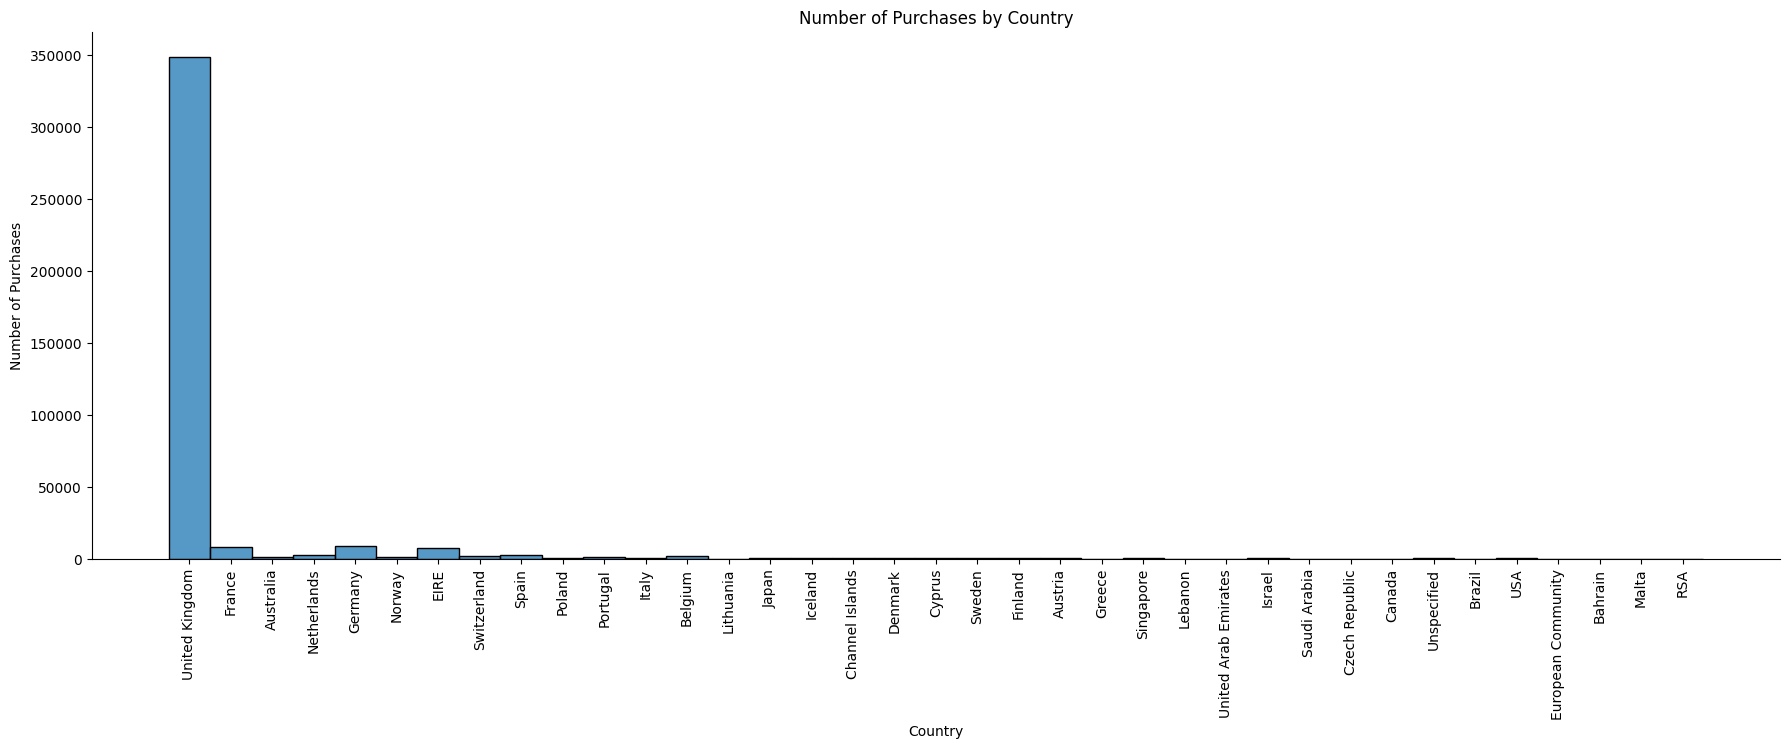

In [30]:
sns.displot(df_cleaned, x="Country", height=6, aspect=3)
plt.title('Number of Purchases by Country')
plt.xlabel('Country')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=90)

plt.show()

**The chart shows that the highest number of purchases is made in the United Kingdom.**

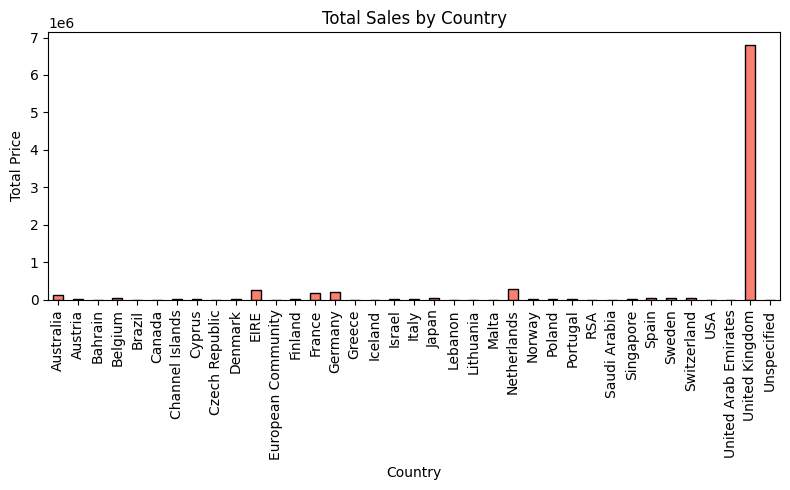

In [31]:
data_grouped = df_cleaned.groupby(['Country'])['TotalPrice'].sum()

data_grouped.plot(kind='bar', figsize=(8, 5), color='salmon')

plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

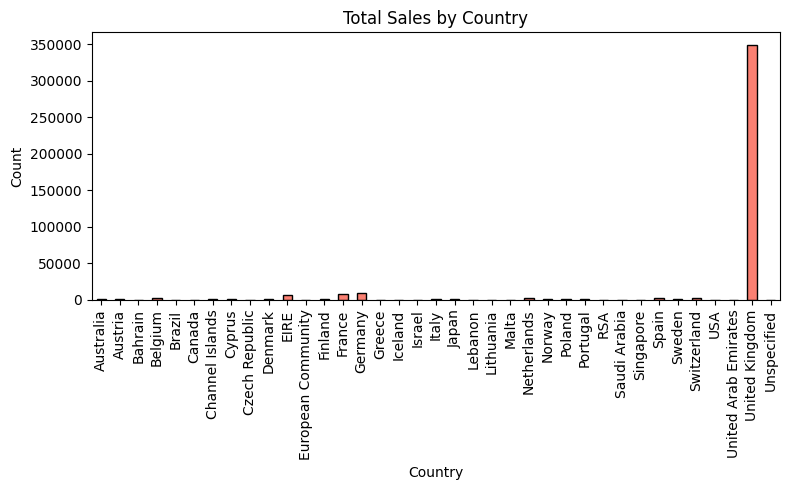

In [32]:
data_grouped = df_cleaned.groupby(['Country'])['TotalPrice'].count()

data_grouped.plot(kind='bar', figsize=(8, 5), color='salmon')

plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:

df_cleaned['Invoice_month'] = df_cleaned['InvoiceDate'].dt.month
df_cleaned['Invoice_seasons'] = df_cleaned['Invoice_month'].apply(
    lambda x: 'winter' if x in (1, 2, 12) 
    else 'spring' if x in (3, 4, 5) 
    else 'summer' if x in (6, 7, 8) 
    else 'autumn' if x in (9, 10, 11) 
    else x  
)

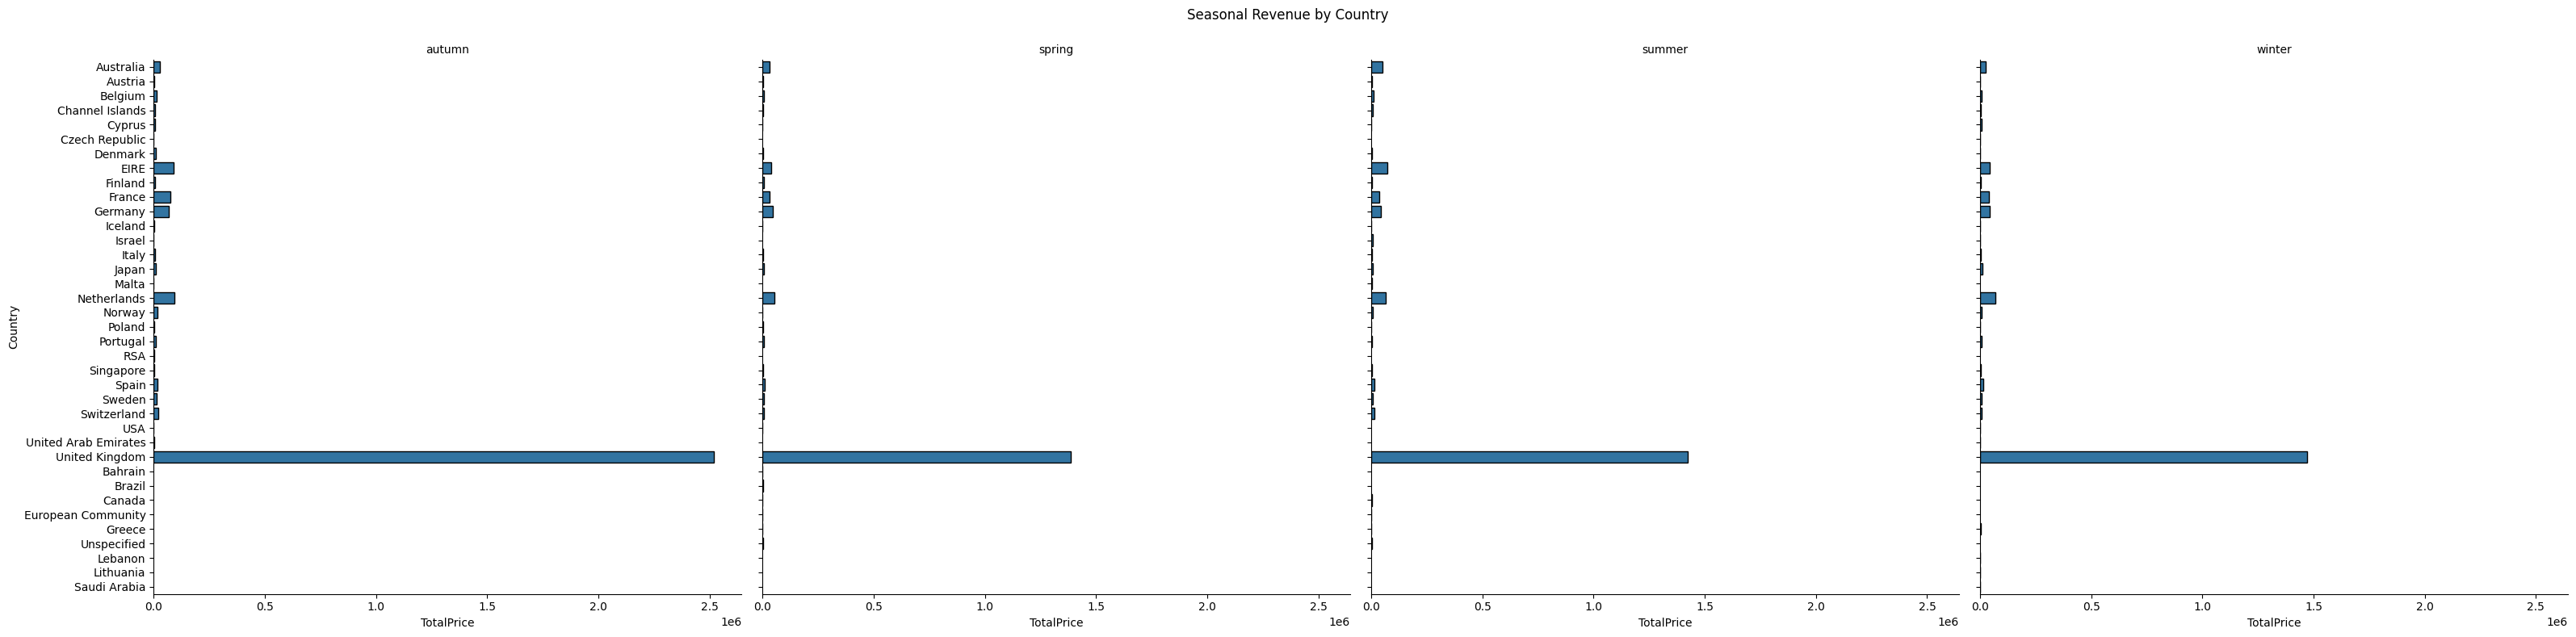

In [35]:
data_grouped = df_cleaned.groupby(['Invoice_seasons', 'Country'])['TotalPrice'].sum()

df_max = data_grouped.reset_index()

# Создаем FacetGrid, разделяя график по 'Invoice_seasons'
g = sns.FacetGrid(df_max, col='Invoice_seasons', col_wrap=4, height=8)

# Строим barplot для каждого сезона
g.map(sns.barplot, 'TotalPrice', 'Country')

# Настроим заголовки и подписи
g.set_axis_labels('TotalPrice', 'Country')
g.set_titles("{col_name}")

# Добавим общий заголовок
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Seasonal Revenue by Country')

plt.show()

In [36]:
# For each season, keep only the row with the maximum total revenue
df_max_season = df_max.loc[df_max.groupby('Invoice_seasons')['TotalPrice'].idxmax()]
df_max_season.rename(columns={'TotalPrice': 'MaxTotalPrice'}, inplace=True)

# print
print(df_max_season)

    Invoice_seasons         Country  MaxTotalPrice
27           autumn  United Kingdom     2518047.13
55           spring  United Kingdom     1385434.29
83           summer  United Kingdom     1424175.58
114          winter  United Kingdom     1470547.34


**The United Kingdom is the leader in seasonal revenue across all four seasons.**

In [37]:
data_gr_seas = df_cleaned.groupby(['Invoice_seasons'])['TotalPrice'].sum()

data_gr_seas.sort_values(ascending=False)

Invoice_seasons
autumn    3016039.50
summer    1797071.43
winter    1783934.83
spring    1667291.68
Name: TotalPrice, dtype: float64

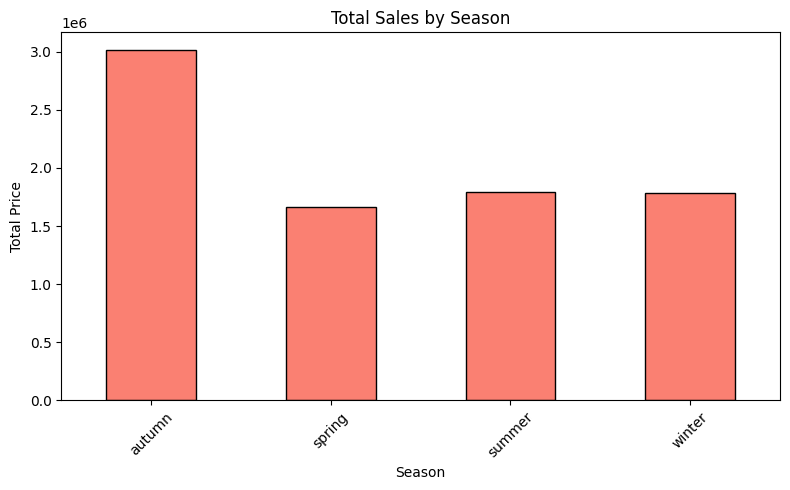

In [38]:


data_gr_seas.plot(kind='bar', figsize=(8, 5), color='salmon')

plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**The chart shows that autumn sales are nearly twice as high as in the other seasons.**

In [39]:
df_cleaned['InvoiceDay'] = df_cleaned['InvoiceDate'].dt.date 
df_cleaned['InvoiceHour'] = df_cleaned['InvoiceDate'].dt.hour

In [40]:
df_grouped_day = df_cleaned.groupby(['InvoiceDay', 'InvoiceHour'])['InvoiceNo'].count()
df_day = df_grouped_day.reset_index()
df_day

,InvoiceDay,InvoiceHour,InvoiceNo
0,2010-12-01,8,45
1,2010-12-01,9,149
2,2010-12-01,10,114
3,2010-12-01,11,351
4,2010-12-01,12,412
...,...,...,...
2848,2011-12-09,8,112
2849,2011-12-09,9,58
2850,2011-12-09,10,128
2851,2011-12-09,11,131


In [41]:
df_day_grouped = df_day.groupby('InvoiceHour')['InvoiceNo'].mean().round(2)
df_day_grouped

InvoiceHour
6       1.00
7      16.30
8      42.27
9      86.46
10    123.95
11    158.58
12    231.86
13    207.95
14    176.25
15    148.22
16     89.49
17     70.48
18     61.36
19     65.90
20     55.50
Name: InvoiceNo, dtype: float64

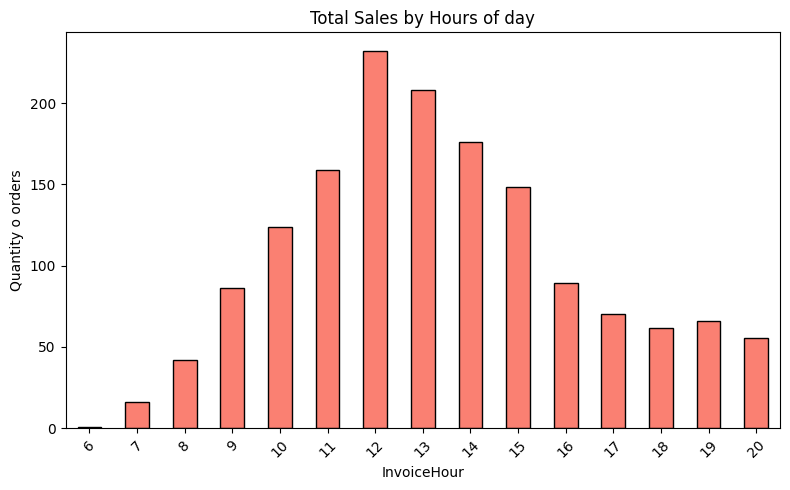

In [42]:
df_day_grouped.plot(kind='bar', figsize=(8, 5), color='salmon')

plt.title('Total Sales by Hours of day')
plt.xlabel('InvoiceHour')
plt.ylabel('Quantity o orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Sales begin to rise steadily from 7 AM to 11 AM, followed by a noticeable spike at 12 PM. After that, they gradually decline until 4 PM, and from 5 PM to 8 PM, sales remain relatively stable.**

#### **Conclusions:**
**Exploratory data analysis revealed that the highest number of purchases are made in the United Kingdom. Autumn is the peak sales season, and the most active sales hours fall between 9 AM and 4 PM.**

### 2.3. Building the RFM table and detecting RFM outliers

We've reached the most exciting part of our task — it's time to engineer features that will serve as the foundation for customer segmentation.

To do this, let's explore a widely used method for analyzing customer value called RFM analysis. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

The method involves grouping customers based on the following parameters:

* Recency — how recently the customer made their last purchase;

* Frequency — the total number of purchases made by the customer;

* Monetary Value — the total amount of money


The essence of RFM analysis is to segment all customers based on how recently they made a purchase, how frequently they buy, and how much they spend.

For example, here’s how cluster interpretation might look in the case of RF segmentation (based on recency and frequency only):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

The marketer’s goal is to guide customers toward the loyal segment.

We can calculate the RFM characteristics for each customer in our dataset and use clustering techniques to build similar customer segments based on our own data

To create the RFM table, we need to group the data by customer ID and calculate the following aggregated metrics:

* Recency for the i-th customer is calculated as the number of days between their most recent purchase and a chosen reference date:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    We use December 10, 2011 ('2011-12-10 00:00:00') as the reference point  $t_0$ which is one day after the last date in our dataset.

* Frequency is calculated as the total number of unique orders made by the i-th customer.
* Monetary Value is the total amount of money the i-th customer spent on our products (accounting for returns).

Once you’ve calculated all the metrics, don’t forget to assign clear and appropriate column names to the resulting RFM table.

In [43]:
# the reference point
snapshot_date = pd.to_datetime('2011-12-10 00:00:00')

# group by client
rfm_table = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,          # Recency
    'InvoiceNo': 'nunique',                                           # Frequency
    'TotalPrice': 'sum'                                               # Monetary
})

# rename the columns
rfm_table.columns = ['Recency', 'Frequency', 'Monetary']

# print the result
print(rfm_table.head())

            Recency  Frequency  Monetary
CustomerID                              
12346           325          1      0.00
12347             2          7   4310.00
12348            75          4   1437.24
12349            18          1   1457.55
12350           310          1    294.40


Once you’ve prepared the RFM table, visualize each of the three components using boxplots (or other appropriate charts). You’ll get results similar to the examples below (note that the exact visuals may vary depending on how you performed data preprocessing):

In [43]:
boxes = [px.box(rfm_table, x=column) for column in rfm_table.columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency","Frequency", "Monetary"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
#fig.write_html('plotly/boxplot_1.html')
fig.show()

What can we observe here? There are customers with an unusually high number of purchases (over 100), as well as customers whose total spending exceeds £190,000.

Why is this a problem? Outliers like these can negatively impact clustering algorithms that are sensitive to them — such as KMeans. Ideally, we want to remove them, but without losing too much valuable customer data.

To address this, we’ll apply an upper threshold based on the 95th percentile. In other words, we’ll exclude customers whose Frequency or Monetary values are higher than 95% of all others.


In [44]:
# Calculate the 95th percentile for Frequency and Monetary
freq_threshold = rfm_table['Frequency'].quantile(0.95)
monetary_threshold = rfm_table['Monetary'].quantile(0.95)

# Filter the dataset to keep only rows below the 95th percentile thresholds
rfm_filtered = rfm_table[
    (rfm_table['Frequency'] <= freq_threshold) &
    (rfm_table['Monetary'] <= monetary_threshold)
]

# print the result
print(rfm_filtered.describe())

           Recency    Frequency     Monetary
count  4044.000000  4044.000000  4044.000000
mean     97.485410     3.009891   975.882648
std     101.181582     2.539113  1024.209011
min       0.000000     1.000000     0.000000
25%      21.000000     1.000000   281.290000
50%      56.000000     2.000000   594.340000
75%     155.000000     4.000000  1304.775000
max     373.000000    13.000000  5657.850000


## 3. Building the Model and Evaluating Its Performance

### 3.1. Clustering Based on RFM Features

To make the clustering results easier to interpret, you can reduce the dimensionality of the original features to two components

**Hint.** Dimensionality reduction techniques require the data to be standardized or normalized. For convenience, wrap the preprocessing steps in a pipeline.

Perform preprocessing on the RFM features. Then, cluster the online gift store’s customers using at least three different clustering algorithms that you’re familiar with.

Select the optimal number of clusters for each method by computing the silhouette score, iterating over cluster counts from 3 to 10 (as more or fewer clusters are typically irrelevant for marketing purposes).

Choose the algorithm that yields the highest silhouette score and use it to generate the final cluster labels.

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2))])
data_norm = pipe.fit_transform(rfm_filtered)

In [76]:
data_norm.shape

(4044, 2)

### KMeans

Determine the optimal number of clusters using the silhouette method

<Axes: xlabel='cluster', ylabel='silhouette'>

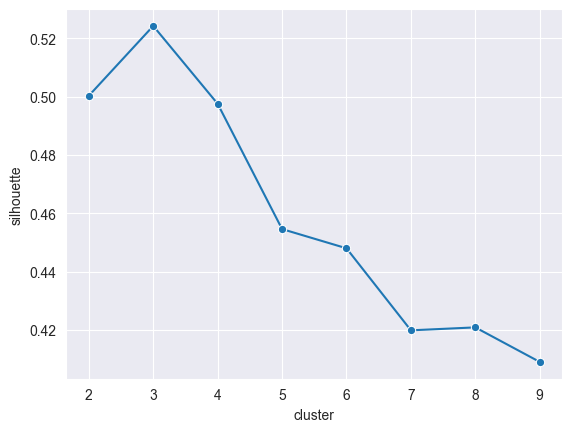

In [46]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


def get_silhouette(cluster_num, X):
    
    k_means =  KMeans(n_clusters=cluster_num, init='k-means++', n_init=10, random_state=42)
    k_means.fit(X)
# Calculate the silhouette score using the data and cluster labels
    silhouette = silhouette_score(X, k_means.predict(X))
    return silhouette

# Create an empty dictionary to store inertia values for each number of clusters
silhouette_res = {"silhouette": [], "cluster": []}

# Select relevant data 
X = data_norm

for cluster_num in range(2, 10):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, X))
    silhouette_res["cluster"].append(cluster_num)
    
# Store silhouette score and number of clusters in a DataFrame
silhouette_df = pd.DataFrame(silhouette_res)

# select the visualize style
sns.set_style("darkgrid")
# Plot the relationship between inertia and the number of clusters
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

According to the silhouette method, the optimal number of clusters is 3.
Let’s train the KMeans algorithm using 3 clusters.

In [47]:

model_km = KMeans(n_clusters=3, random_state=42).fit(data_norm)

In [48]:
kmeans_predictions = model_km.fit_predict(data_norm)
rfm_filtered["clusters_3d_kmeans"] = kmeans_predictions
rfm_filtered.clusters_3d_kmeans.value_counts()

clusters_3d_kmeans
2    2269
0     999
1     776
Name: count, dtype: int64

### DBSCAN

Determine the parameters eps and min_samples for DBSCAN using the silhouette method.

In [ ]:
from sklearn.cluster import DBSCAN

siliuette_list_dbscan = []

for eps in np.arange(0.1, 2, 0.1):
    for min_sample in range(1, 10, 1):
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        dbscan.fit(data_norm)

        labels = dbscan.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  

        if n_clusters >= 2:
            sil_score = silhouette_score(data_norm, labels, metric='euclidean')
        else:
            sil_score = np.nan  

        siliuette_list_dbscan.append((eps, min_sample, sil_score, n_clusters))

df_dbscan = pd.DataFrame(
    siliuette_list_dbscan,
    columns=['eps', 'min_samples', 'sil_score', 'number_of_clusters']
)

# Sort by silhouette score in descending order (highest-quality clusters first)
df_dbscan.sort_values(by='sil_score', ascending=False, inplace=True)

print(df_dbscan.head())

    eps  min_samples  sil_score  number_of_clusters
46  0.6            2   0.395847                   2
45  0.6            1   0.395847                   3
36  0.5            1   0.362367                   5
27  0.4            1   0.215060                   7
13  0.2            5   0.137606                   3


Train the model using the best-performing parameters.

In [51]:
model_dbscan = DBSCAN(eps=0.6, min_samples=2)
labels = model_dbscan.fit_predict(data_norm)

In [52]:
# add mark cluster in data
rfm_filtered["clusters_3d_dbscan"] = labels
len(set(labels)) - (1 if -1 in labels else 0)

2

### AgglomerativeClustering

Determine clusters number  for Agglomerative Clustering using the silhouette method.

In [54]:
from sklearn.cluster import AgglomerativeClustering


siliuette_list_aggl = []
 
for n_clusters in np.arange(2,6):
        agglscan = AgglomerativeClustering(n_clusters=n_clusters)
        agglscan.fit(data_norm)
        sil_score = silhouette_score(data_norm, agglscan.labels_, metric='euclidean')
        siliuette_list_aggl.append((n_clusters, sil_score, len(set(agglscan.labels_))) )
df_agglscan = pd.DataFrame(siliuette_list_aggl, columns=['n_clusters', 'sil_score', 'number_of_clusters'])
df_agglscan.sort_values(by = 'sil_score')

,n_clusters,sil_score,number_of_clusters
3,5,0.433023,5
2,4,0.458894,4
1,3,0.468828,3
0,2,0.486359,2


The method indicated that the optimal number of clusters is 2.
Let’s train the model using these parameters.

In [55]:
model_ac = AgglomerativeClustering(n_clusters=2, affinity='euclidean').fit(data_norm)
rfm_filtered['cluster_id_ac'] = model_ac.labels_
rfm_filtered['cluster_id_ac'].value_counts()

cluster_id_ac
0    2950
1    1094
Name: count, dtype: int64

### 3.2. Interpretation of Clustering Results

Let’s move on to interpreting the resulting clusters.

#### 3.2.1. Cluster Visualization

Visualize the clustering results using a 3D plot with Recency, Frequency, and Monetary as the axes.
Analyze the resulting diagram and try to understand the characteristics of each cluster.

**Kmeans**

Text(0.5, 0, 'Monetary')

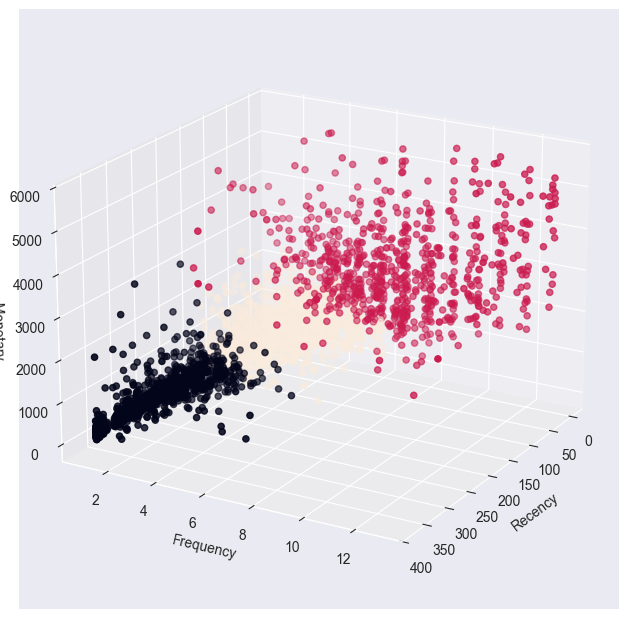

In [56]:
from mpl_toolkits.mplot3d import Axes3D
rfm_filtered["clusters_3d_kmeans"]
# Create a 3D plot object
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig)
#  Add a third axis to the plot object
fig.add_axes(ax)

ax.azim = 30
ax.elev = 20

# Visualize the data by passing x, y, z values and using color to represent cluster grouping
ax.scatter(rfm_filtered.Recency.to_list(), rfm_filtered.Frequency.to_list(), rfm_filtered.Monetary.to_list(), c=rfm_filtered.clusters_3d_kmeans)
# Add axises
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

**Dbscan**

Text(0.5, 0, 'Monetary')

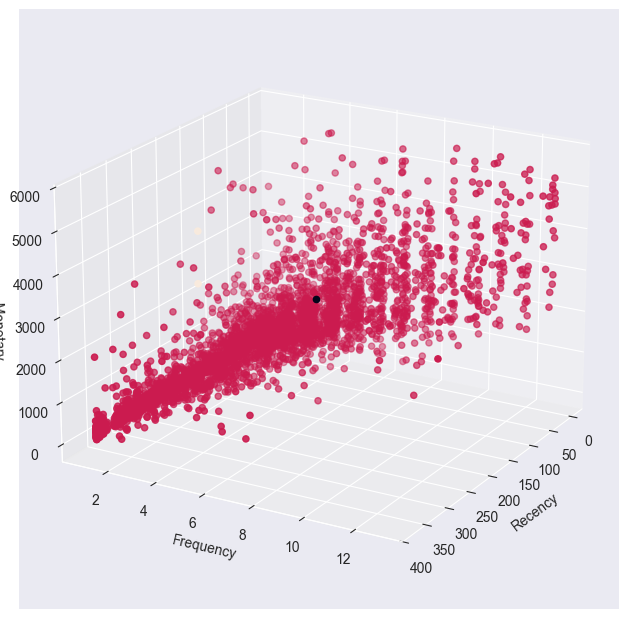

In [57]:
# Create a 3D plot object
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig)
# Add a third axis to the plot object
fig.add_axes(ax)
ax.azim = 30
ax.elev = 20

# Visualize the data by passing x, y, z values and using color to represent cluster grouping
ax.scatter(rfm_filtered.Recency.to_list(), rfm_filtered.Frequency.to_list(), rfm_filtered.Monetary.to_list(), c=rfm_filtered.clusters_3d_dbscan)
# Add axises
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

**AgglomerativeClustering**

Text(0.5, 0, 'Monetary')

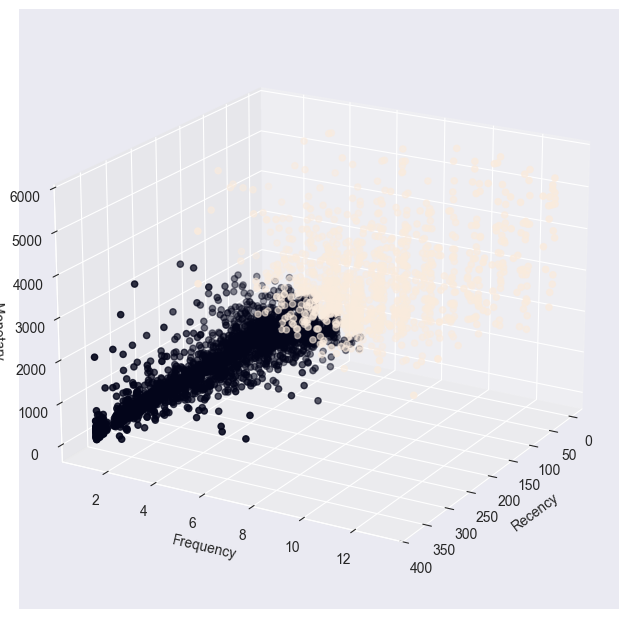

In [58]:
# Create a 3D plot object
fig = plt.figure(figsize=(8,6))
ax = Axes3D(fig)
# Add a third axis to the plot object
fig.add_axes(ax)
ax.azim = 30
ax.elev = 20
# Visualize the data by passing x, y, z values and using color to represent cluster grouping
ax.scatter(rfm_filtered.Recency.to_list(), rfm_filtered.Frequency.to_list(), rfm_filtered.Monetary.to_list(), c=rfm_filtered.cluster_id_ac)
# Add axises
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

In [59]:
import plotly
import plotly.express as px

fig = px.scatter_3d(
    data_frame=rfm_filtered, 
    x = 'Recency', 
    y = 'Frequency', 
    z = 'Monetary', 
    color='cluster_id_ac', 

    width=1000,
    height=700
)

fig.show()

**We built three clustering models: KMeans, DBSCAN, and AgglomerativeClustering.**
**The visualization showed that DBSCAN grouped nearly all the data into a single cluster, with only a small portion assigned to a second cluster. In contrast, KMeans and AgglomerativeClustering achieved a more meaningful and well-separated clustering.**


#### 3.2.2. Building Cluster Profiles

Next, create what's known as a cluster profile. To do this, return from the decomposed data (if you performed dimensionality reduction) back to the cleaned RFM table.

Group the RFM table by the assigned cluster labels and calculate the mean of each RFM feature within each cluster.

To make the results easier to interpret, let’s explore one way to visualize cluster profiles — **Radar Chart** (also known as a spider chart). A radar chart  is a graphical method of displaying multivariate data in the form of a web. 

Radar charts are commonly used when interpreting cluster profiles. Each axis represents a feature describing the objects, and each cluster’s average value for that feature is plotted along the corresponding axis. Connecting these points creates a polygon that visually represents the profile of each cluster.

Here’s an example of a radar chart used for clustering students based on their interests:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

This chart visualizes the feature profile of one of the clusters.
It shows that students in this cluster are more interested in Music, while they are less engaged in Programming.

The plotly.graph_objects module includes a built-in Scatterpolar function that allows you to create radar (polar) charts. Based on this, we’ve prepared a custom function called plot_cluster_profile() to help you visualize the profile of each cluster as a radar chart.

This function takes two parameters:

* grouped_data: the cluster-aggregated characteristics of the objects (e.g., customers),

* n_clusters: the number of clusters.

The key requirement for radar charts is that all features must be scaled to a common range using normalization, where 1 represents the maximum and 0 the minimum.
This normalization step is also built into the plot_cluster_profile() function

In [60]:
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing

def plot_cluster_profile(grouped_data, n_clusters):
    """Функция для визуализации профиля кластеров в виде полярной диаграммы.

    Args:
        grouped_data (DataFrame): таблица, сгруппированная по номерам кластеров с агрегированными характеристиками объектов.
        n_clusters (int): количество кластеров
    """
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаём список признаков
    features = grouped_data.columns
    # Создаём пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаём полярную диаграмму и добавляем её на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название — номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()

Now you have a convenient tool for analyzing cluster profiles.
Use it to interpret the results obtained in the previous step.

**Kmeans**

In [68]:
data_grouped_1 = rfm_filtered.groupby('clusters_3d_kmeans')

print(data_grouped_1)

In [74]:
data_grouped_kmeans = rfm_filtered.groupby('clusters_3d_kmeans').agg({
    'Recency':'sum',
    'Frequency': 'sum',
    'Monetary': 'sum'
    })


In [75]:
plot_cluster_profile(data_grouped_kmeans, 3)

The KMeans clustering results showed the following patterns:

* Cluster 0: Recency is the most significant feature, while Frequency and Monetary appear to be of little importance.

* Cluster 1: Frequency is the most influential feature, followed by Monetary, with Recency being the least relevant.

* Cluster 2: Recency plays almost no role, while Frequency and Monetary are equally important.

**DBSCAN**

In [63]:
data_grouped_dbscan = rfm_filtered.groupby('clusters_3d_dbscan').agg({
    'Recency':'sum',
    'Frequency': 'sum',
    'Monetary': 'sum'
    })

In [64]:
plot_cluster_profile(data_grouped_dbscan, 2)


The dbscan clustering results showed the following patterns:

* Cluster 0: 

* Cluster 1: All 3 features are important: Frequency, Monetary и Recency 



**AgglomerativeClustering**

In [65]:
data_grouped_ac = rfm_filtered.groupby('cluster_id_ac').agg({
    'Recency':'sum',
    'Frequency': 'sum',
    'Monetary': 'sum'
    })

In [66]:

plot_cluster_profile(data_grouped_ac, 2)

The AgglomerativeClustering results showed the following patterns:

* Cluster 0: Recency is the most significant feature, while Frequency and Monetary appear to be of little importance.

* Cluster 1: All 3 features are important: Frequency, Monetary и Recency 



## 4. Conclusions

Напишите заключение о проделанной работе и полученных результатах. Отметьте, какие сегменты клиентов вам удалось найти в данных.

После завершения проекта создайте в своём репозитории файл README.md и кратко опишите содержимое проекта по принципу, который мы приводили ранее.

Выложите свой проект на GitHub и оформите удалённый репозиторий, добавив в него описание и теги репозитория (теги придумайте самостоятельно в зависимости от того, какую задачу вы решали).

**In this project, we analyzed customer data from an online gift store and built clustering models.
Two models produced the most effective segmentation results, allowing us to identify the following customer segments.**

The KMeans clustering identified three customer groups:

* Cluster 1: customers with the longest time since their last purchase.

* Cluster 2: customers with a high number of purchases and above-average spending, with a moderate recency level.

* Cluster 3: customers with the highest purchase frequency and the largest monetary value.

The AgglomerativeClustering algorithm identified two clusters:

* Cluster 1: customers with the longest time since their last purchase.

* Cluster 2: customers with the highest spending and purchase frequency.
